In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import hydropandas as hpd

hpd.util.get_color_logger("INFO")

# pd.set_option("display.max_rows", None)
# pd.set_option("display.max_columns", None)
# pd.set_option("display.width", None)

<RootLogger root (INFO)>

In [2]:
organisation = "rotterdam"

auth = ("__key__", "D5aclEis.RBUeIvKA6jrLVUzNpPATjvGyLXsLAx7P")

In [3]:
my_extent = (89945, 91552, 440688, 441553) 
oc = hpd.read_lizard(
    extent=my_extent,
    which_timeseries=["hand", "diver", "diver_validated"],
    datafilters=None,
    combine_method="merge",
    organisation=organisation,
    auth=auth,
)

INFO:hydropandas.io.lizard.get_obs_list_from_extent:Number of monitoring wells: 10
INFO:hydropandas.io.lizard.get_obs_list_from_extent:Number of pages: 1


monitoring well: 100%|██████████| 10/10 [00:03<00:00,  3.04it/s]


In [4]:
oc.plots.interactive_map(
    color="red",
    zoom_start=15,
    tiles="Esri.WorldImagery",
    popup_width=350
)

In [5]:
oc

,x,y,location,filename,source,unit,tube_nr,screen_top,screen_bottom,ground_level,tube_top,metadata_available,obs,lat,lon
name,,,,,,,,,,,,,,,
GMW000000036741001,90998.687871,441239.318459,MEIJPL-12,,lizard,m NAP,1,-15.680,-16.680,-4.560,-2.680,True,GroundwaterObs GMW000000036741001 -----metadat...,51.955901,4.456115
GMW000000036965001,91525.037726,441090.628347,128572-792,,lizard,m NAP,1,-5.970,-6.970,-4.850,-4.970,True,GroundwaterObs GMW000000036965001 -----metadat...,51.954625,4.463799
GMW000000036989001,90664.868686,441145.728338,127572-1,,lizard,m NAP,1,-5.150,-7.150,-4.340,-4.350,True,GroundwaterObs GMW000000036989001 -----metadat...,51.955021,4.451277
GMW000000037445001,90407.518334,440789.329306,127571-4,,lizard,m NAP,1,-5.390,-7.390,-4.830,-4.890,True,GroundwaterObs GMW000000037445001 -----metadat...,51.951788,4.447601
GMW000000038220001,91303.067938,441217.968233,128572-795,,lizard,m NAP,1,-16.560,-18.560,-4.680,-3.560,True,GroundwaterObs GMW000000038220001 -----metadat...,51.955744,4.460547
GMW000000098093001,91547.087277,441459.765282,128572-798,,lizard,m NAP,1,-6.807,-7.807,-4.807,-4.884,True,GroundwaterObs GMW000000098093001 -----metadat...,51.957945,4.464052
GMW000000101405001,91513.987745,441096.026782,128572-9,,lizard,m NAP,1,-6.410,-7.410,-4.860,-4.860,True,GroundwaterObs GMW000000101405001 -----metadat...,51.954672,4.463637
GMW000000101406001,91466.987589,441235.026233,128572-12,,lizard,m NAP,1,-6.390,-7.390,-4.840,-4.840,True,GroundwaterObs GMW000000101406001 -----metadat...,51.955916,4.462928
GMW000000101454001,91522.988168,440812.027927,128571-3,,lizard,m NAP,1,-6.390,-7.390,-4.740,-4.740,True,GroundwaterObs GMW000000101454001 -----metadat...,51.952121,4.463821


In [6]:
gw = oc.obs["GMW000000036965001"]
print(gw)

GroundwaterObs GMW000000036965001
-----metadata------
name : GMW000000036965001 
x : 91525.03772620695 
y : 441090.6283468774 
location : 128572-792 
filename :  
source : lizard 
unit : m NAP 
tube_nr : 1 
screen_top : -5.97 
screen_bottom : -6.97 
ground_level : -4.85 
tube_top : -4.97 
metadata_available : True 

-----time series------
                     value  flag  comment origin
peil_datum_tijd                                 
2011-11-15 00:00:00  -5.96   NaN  Gemeten   hand
2012-01-17 14:58:00  -5.87   NaN  Gemeten   hand
2012-03-12 10:02:00  -5.89   NaN  Gemeten   hand
2012-05-09 23:00:00  -5.76   NaN  Gemeten   hand
2012-07-13 19:59:00  -5.83   NaN  Gemeten   hand
...                    ...   ...      ...    ...
2025-12-15 09:25:29  -5.70   2.0           diver
2025-12-15 13:25:31  -5.71   2.0           diver
2025-12-15 17:25:32  -5.71   2.0           diver
2025-12-15 21:25:34  -5.71   2.0           diver
2025-12-16 01:25:36  -5.72   2.0           diver

[7773 rows x 4 column

In [7]:
ts = gw["value"].copy()
ts.index = pd.to_datetime(ts.index)
ts = ts.dropna()

print(ts.index.min(), ts.index.max())
print(ts.shape)

2011-11-15 00:00:00 2025-12-16 01:25:36
(7769,)


In [8]:
ts_year = ts.loc["2024-11-01":"2025-10-31"]

ts_daily_raw = ts_year.resample("D").mean()

ts_daily = ts_daily_raw.interpolate(method="time")

is_interpolated = ts_daily_raw.isna()

In [9]:
percentile = 0.30

# === FIXED THRESHOLD ===
threshold_fixed = ts_year.quantile(percentile)

# === VARIABLE THRESHOLD ===
monthly_threshold = (
    ts_year
    .groupby(ts_year.index.month)
    .quantile(percentile)
    .reindex(range(1, 13))          # zorg dat alle maanden bestaan
)

n_months_with_data = monthly_threshold.notna().sum()

if n_months_with_data < 6:
    print(
        f"Not enough data for variable threshold ({n_months_with_data} months). "
        "Variable threshold will not be used."
    )
    threshold_variable_smooth = None
else:
    monthly_threshold = monthly_threshold.interpolate(method="linear")

    threshold_variable = ts_daily.index.to_series().map(
        lambda d: monthly_threshold.loc[d.month]
    )

    threshold_variable_smooth = (
        threshold_variable
        .rolling(window=20, min_periods=1)
        .mean()
    )

# === KIES welke threshold wordt gebruikt voor DROOGTE ===
threshold = threshold_variable_smooth if threshold_variable_smooth is not None else threshold_fixed


In [10]:
is_drought_fixed = ts_daily < threshold_fixed

if threshold_variable_smooth is not None:
    is_drought_variable = ts_daily < threshold_variable_smooth
else:
    is_drought_variable = None

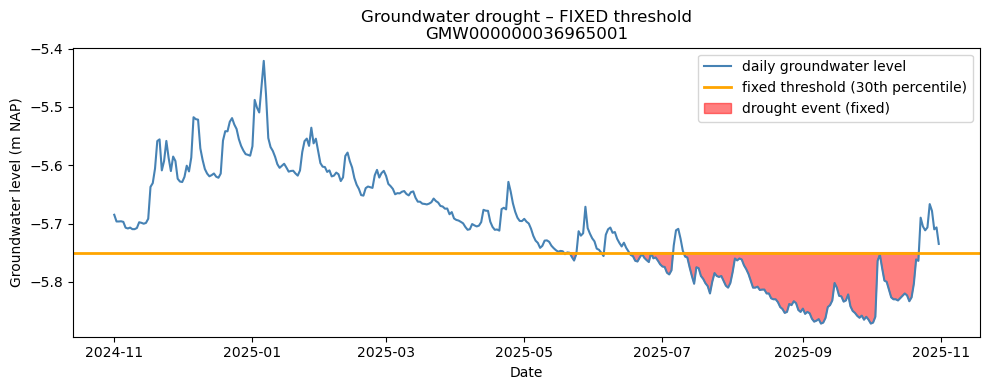

In [11]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(
    ts_daily.index,
    ts_daily,
    color="steelblue",
    linewidth=1.5,
    label="daily groundwater level",
)

ax.axhline(
    threshold_fixed,
    color="orange",
    linewidth=2,
    linestyle="-",
    label="fixed threshold (30th percentile)",
)

ax.fill_between(
    ts_daily.index,
    ts_daily,
    threshold_fixed,
    where=is_drought_fixed,
    color="red",
    alpha=0.5,
    label="drought event (fixed)",
    interpolate=True,
)

ax.set_ylabel("Groundwater level (m NAP)")
ax.set_xlabel("Date")
ax.set_title(f"Groundwater drought – FIXED threshold\n{gw.name}")
ax.legend()

plt.tight_layout()
plt.show()


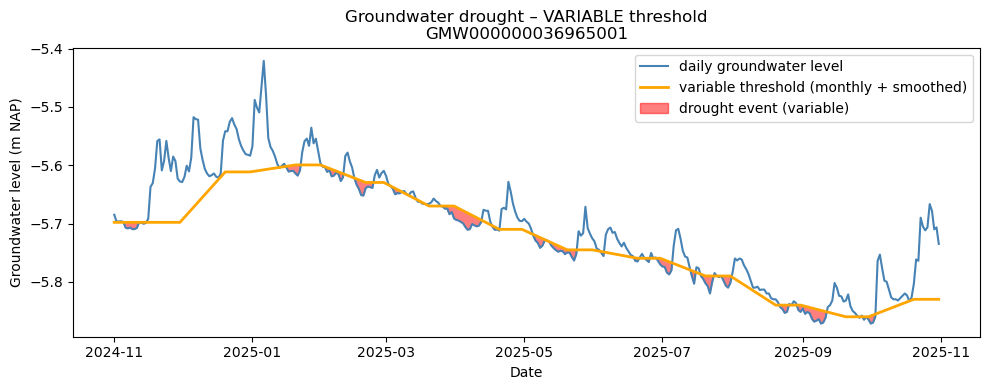

In [12]:
if threshold_variable_smooth is not None:
    fig, ax = plt.subplots(figsize=(10, 4))

    ax.plot(
        ts_daily.index,
        ts_daily,
        color="steelblue",
        linewidth=1.5,
        label="daily groundwater level",
    )

    ax.plot(
        threshold_variable_smooth.index,
        threshold_variable_smooth.values,
        color="orange",
        linewidth=2,
        label="variable threshold (monthly + smoothed)",
    )

    ax.fill_between(
        ts_daily.index,
        ts_daily,
        threshold_variable_smooth,
        where=is_drought_variable,
        color="red",
        alpha=0.5,
        label="drought event (variable)",
        interpolate=True,
    )

    ax.set_ylabel("Groundwater level (m NAP)")
    ax.set_xlabel("Date")
    ax.set_title(f"Groundwater drought – VARIABLE threshold\n{gw.name}")
    ax.legend()

    plt.tight_layout()
    plt.show()
else:
    print("Variable threshold plot skipped: insufficient data.")


In [13]:
# =========================
# SAMENVATTING – FIXED THRESHOLD
# =========================
duration_fixed = is_drought_fixed.sum()
max_deficit_fixed = (threshold_fixed - ts_daily[is_drought_fixed]).max()

n_interpolated = is_interpolated.sum()

print("=== FIXED THRESHOLD (30th percentile) ===")
print(
    f"Drought duration (2024–2025): {duration_fixed} days. "
    f"{n_interpolated} days were interpolated."
)
print(f"Maximum deficit (2024–2025): {max_deficit_fixed:.2f} m\n")


# =========================
# SAMENVATTING – VARIABLE THRESHOLD
# =========================
if is_drought_variable is not None:
    duration_variable = is_drought_variable.sum()
    max_deficit_variable = (
        threshold_variable_smooth - ts_daily[is_drought_variable]
    ).max()

    print("=== VARIABLE THRESHOLD (monthly 30th percentile + smoothing) ===")
    print(
        f"Drought duration (2024–2025): {duration_variable} days. "
        f"{n_interpolated} days were interpolated."
    )
    print(f"Maximum deficit (2024–2025): {max_deficit_variable:.2f} m\n")
else:
    print("=== VARIABLE THRESHOLD ===")
    print("Not enough data to compute variable threshold.\n")


# =========================
# DAGELIJKS OVERZICHT (WAARDES + HERKOMST)
# =========================
origin_per_day = (
    gw[["value", "origin"]]
    .dropna()
    .assign(date=lambda df: df.index.normalize())
    .groupby("date")["origin"]
    .agg(lambda x: ",".join(sorted(set(x))))
)

summary = pd.DataFrame({
    "value": ts_daily,
    "interpolated": is_interpolated,
})

summary["origin"] = origin_per_day
summary.loc[summary["interpolated"], "origin"] = "interpolated"

summary


=== FIXED THRESHOLD (30th percentile) ===
Drought duration (2024–2025): 130 days. 2 days were interpolated.
Maximum deficit (2024–2025): 0.12 m

=== VARIABLE THRESHOLD (monthly 30th percentile + smoothing) ===
Drought duration (2024–2025): 136 days. 2 days were interpolated.
Maximum deficit (2024–2025): 0.03 m



,value,interpolated,origin
peil_datum_tijd,,,
2024-11-01,-5.685000,False,diver_validated
2024-11-02,-5.696500,False,diver_validated
2024-11-03,-5.696500,False,diver_validated
2024-11-04,-5.696167,False,diver_validated
2024-11-05,-5.697167,False,diver_validated
...,...,...,...
2025-10-27,-5.666667,False,diver
2025-10-28,-5.678333,False,diver
2025-10-29,-5.710000,False,diver
